<div style="display: flex; align-items: center; justify-content: center; gap: 20px;">
    <img src="https://freepnglogo.com/images/all_img/1706465622logo-the-north-face-png.png" alt="Image Gauche" style="width: 200px; height: auto;">
    <div style="text-align: center;">
        <h1>
            <span style="font-weight: bold; color: #ef1d28; text-decoration: underline;">
                The North face ecommerce
            </span>
        </h1>
    </div>
    <img src="https://freepnglogo.com/images/all_img/1706465622logo-the-north-face-png.png" alt="Image Droite" style="width: 200px; height: auto;">
</div>


## Introduction

The North Face, a well-known American outdoor brand, aims to enhance its online shopping experience and boost conversion rates on its e-commerce website. To support this effort, we explore the use of unsupervised machine learning techniques to better understand and organize the product catalog, and to recommend similar items to users.

This project focuses on two main objectives:
- Building a product recommender system based on textual similarity of item descriptions.
- Discovering latent product themes through topic modeling to potentially redefine product categories.

To achieve these goals, we will work with a dataset of product descriptions, and apply three key methodologies:

1. **Clustering similar products** based on their descriptions using DBSCAN and cosine similarity.
2. **Recommender system** that suggests similar items to users based on the clustering results.
3. **Topic modeling** with Latent Semantic Analysis (LSA) using TruncatedSVD to uncover hidden themes across the product catalog.

This notebook guides you through each step — from preprocessing and vectorizing the text, to modeling, analysis, and interpretation — in order to deliver actionable insights for marketing and UX optimization.


## 0. 📥 Data Import & Preprocesssing

In [60]:
# Import pandas and dataset

import pandas as pd
dataset = pd.read_csv("src/sample-data.csv")
data = pd.DataFrame(dataset)

In [61]:
# Dataframe visualization

data.head()

,id,description
0,1,Active classic boxers - There's a reason why o...
1,2,Active sport boxer briefs - Skinning up Glory ...
2,3,Active sport briefs - These superbreathable no...
3,4,"Alpine guide pants - Skin in, climb ice, switc..."
4,5,"Alpine wind jkt - On high ridges, steep ice an..."


In [62]:
# Get 3 columns : title, description and complete

# Ensure we are working on a copy to avoid SettingWithCopyWarning
data = data.copy()

# Split the original 'description' column on the first occurrence of ' - '
split_cols = data['description'].str.split(' - ', n=1, expand=True)
data.loc[:, 'title'] = split_cols[0]
data.loc[:, 'description'] = split_cols[1].fillna('')  # manage missing splits

# Create the 'complete' column combining title + description
data.loc[:, 'complete'] = data['title'] + ' ' + data['description']

# Keep only the relevant columns
data = data[['id','title', 'description', 'complete']]

data.head()


,id,title,description,complete
0,1,Active classic boxers,There's a reason why our boxers are a cult fav...,Active classic boxers There's a reason why our...
1,2,Active sport boxer briefs,Skinning up Glory requires enough movement wit...,Active sport boxer briefs Skinning up Glory re...
2,3,Active sport briefs,These superbreathable no-fly briefs are the mi...,Active sport briefs These superbreathable no-f...
3,4,Alpine guide pants,"Skin in, climb ice, switch to rock, traverse a...","Alpine guide pants Skin in, climb ice, switch ..."
4,5,Alpine wind jkt,"On high ridges, steep ice and anything alpine,...","Alpine wind jkt On high ridges, steep ice and ..."


In [63]:
# Lowercase

data['original_description'] = data['description']
data.loc[:, 'description'] = data['description'].fillna('').str.lower()
data.loc[:, 'complete'] = data['complete'].fillna('').str.lower()

data.head()

,id,title,description,complete,original_description
0,1,Active classic boxers,there's a reason why our boxers are a cult fav...,active classic boxers there's a reason why our...,There's a reason why our boxers are a cult fav...
1,2,Active sport boxer briefs,skinning up glory requires enough movement wit...,active sport boxer briefs skinning up glory re...,Skinning up Glory requires enough movement wit...
2,3,Active sport briefs,these superbreathable no-fly briefs are the mi...,active sport briefs these superbreathable no-f...,These superbreathable no-fly briefs are the mi...
3,4,Alpine guide pants,"skin in, climb ice, switch to rock, traverse a...","alpine guide pants skin in, climb ice, switch ...","Skin in, climb ice, switch to rock, traverse a..."
4,5,Alpine wind jkt,"on high ridges, steep ice and anything alpine,...","alpine wind jkt on high ridges, steep ice and ...","On high ridges, steep ice and anything alpine,..."


In [64]:
# Remove punctuation

data.loc[:, 'description'] = data['description'].str.replace(r"[!\"#$%&()*+,-./:;<=>?@[\\\]^_`{|}~]+", " ", regex=True)
data.loc[:, 'complete'] = data['complete'].str.replace(r"[!\"#$%&()*+,-./:;<=>?@[\\\]^_`{|}~]+", " ", regex=True)
data

,id,title,description,complete,original_description
0,1,Active classic boxers,there's a reason why our boxers are a cult fav...,active classic boxers there's a reason why our...,There's a reason why our boxers are a cult fav...
1,2,Active sport boxer briefs,skinning up glory requires enough movement wit...,active sport boxer briefs skinning up glory re...,Skinning up Glory requires enough movement wit...
2,3,Active sport briefs,these superbreathable no fly briefs are the mi...,active sport briefs these superbreathable no f...,These superbreathable no-fly briefs are the mi...
3,4,Alpine guide pants,skin in climb ice switch to rock traverse a...,alpine guide pants skin in climb ice switch ...,"Skin in, climb ice, switch to rock, traverse a..."
4,5,Alpine wind jkt,on high ridges steep ice and anything alpine ...,alpine wind jkt on high ridges steep ice and ...,"On high ridges, steep ice and anything alpine,..."
...,...,...,...,...,...
495,496,Cap 2 bottoms,cut loose from the maddening crowds and search...,cap 2 bottoms cut loose from the maddening cro...,Cut loose from the maddening crowds and search...
496,497,Cap 2 crew,this crew takes the edge off fickle weather i...,cap 2 crew this crew takes the edge off fickle...,This crew takes the edge off fickle weather. I...
497,498,All-time shell,no need to use that morning times as an umbrel...,all time shell no need to use that morning tim...,No need to use that morning Times as an umbrel...
498,499,All-wear cargo shorts,all wear cargo shorts bask in the glory of swe...,all wear cargo shorts all wear cargo shorts ba...,All-Wear Cargo Shorts bask in the glory of swe...


In [65]:
# Import Spacy for nlp and get stop words

!python -m spacy download en_core_web_md -q
import en_core_web_md
from spacy.lang.en.stop_words import STOP_WORDS
nlp = en_core_web_md.load()

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')


In [66]:
## Tokenize the cleaned document, remove stop-words, numbers and 2 letter-words.

tokenized_doc = data['complete'].fillna('').apply(lambda x: nlp(x))

tokenized_doc = tokenized_doc.apply(lambda doc: [token.lemma_.lower() 
    for token in doc
        if token.text.lower() 
            not in STOP_WORDS      
            and not token.is_digit                      
            and not token.like_num                       
            and len(token.text) > 2                      
            and token.is_alpha                          
])

tokenized_doc.head()

0    [active, classic, boxer, reason, boxer, cult, ...
1    [active, sport, boxer, brief, skin, glory, req...
2    [active, sport, brief, superbreathable, fly, b...
3    [alpine, guide, pant, skin, climb, ice, switch...
4    [alpine, wind, jkt, high, ridge, steep, ice, a...
Name: complete, dtype: object

In [67]:
# Add tokenized_doc as a new column of data

data["clean_token"] = [" ".join(x) for x in tokenized_doc]
data.head()

,id,title,description,complete,original_description,clean_token
0,1,Active classic boxers,there's a reason why our boxers are a cult fav...,active classic boxers there's a reason why our...,There's a reason why our boxers are a cult fav...,active classic boxer reason boxer cult favorit...
1,2,Active sport boxer briefs,skinning up glory requires enough movement wit...,active sport boxer briefs skinning up glory re...,Skinning up Glory requires enough movement wit...,active sport boxer brief skin glory require mo...
2,3,Active sport briefs,these superbreathable no fly briefs are the mi...,active sport briefs these superbreathable no f...,These superbreathable no-fly briefs are the mi...,active sport brief superbreathable fly brief m...
3,4,Alpine guide pants,skin in climb ice switch to rock traverse a...,alpine guide pants skin in climb ice switch ...,"Skin in, climb ice, switch to rock, traverse a...",alpine guide pant skin climb ice switch rock t...
4,5,Alpine wind jkt,on high ridges steep ice and anything alpine ...,alpine wind jkt on high ridges steep ice and ...,"On high ridges, steep ice and anything alpine,...",alpine wind jkt high ridge steep ice alpine ja...


In [68]:
# Tfidf transformation

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(data['clean_token'])


In [69]:
# Vocabulary check

vectorizer.vocabulary_

{'active': 24,
 'classic': 509,
 'boxer': 335,
 'reason': 2371,
 'cult': 719,
 'favorite': 1082,
 'cool': 647,
 'especially': 1009,
 'sticky': 2887,
 'situation': 2714,
 'quick': 2331,
 'dry': 901,
 'lightweight': 1706,
 'underwear': 3269,
 'take': 3042,
 'minimal': 1875,
 'space': 2811,
 'travel': 3189,
 'pack': 2085,
 'expose': 1043,
 'brush': 365,
 'waistband': 3378,
 'offer': 2022,
 'skin': 2727,
 'softness': 2792,
 'panel': 2103,
 'construction': 624,
 'traditional': 3172,
 'fit': 1129,
 'functional': 1236,
 'fly': 1172,
 'recycle': 2380,
 'polyester': 2230,
 'moisture': 1899,
 'wicke': 3454,
 'performance': 2158,
 'inseam': 1537,
 'size': 2715,
 'recyclable': 2379,
 'common': 579,
 'thread': 3107,
 'recycling': 2382,
 'program': 2285,
 'detail': 810,
 'silky': 2693,
 'capilene': 419,
 'fabric': 1060,
 'ultralight': 3249,
 'breathable': 343,
 'elastic': 946,
 'comfort': 570,
 'recycled': 2381,
 'gladiodor': 1277,
 'natural': 1949,
 'odor': 2020,
 'control': 638,
 'garment': 1250,


In [70]:
# Create a tf-idf dataframe for each token and each document

tfidf_array = X.toarray()

tfidf_df = (pd.DataFrame(tfidf_array, 
             columns=[x for x in vectorizer.get_feature_names_out()], 
             index=["product_{}".format(x) for x in range(len(tfidf_array))] ))

tfidf_df.head()

,abandon,ability,able,abrasion,abrasive,abroad,absolute,absorb,absorption,abstract,...,yvon,zest,zinger,zip,zipped,zipper,zippered,zippers,zips,zone
product_0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0
product_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0
product_2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0
product_3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.107904,0.159722,0.131708,0.0,0.0
product_4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.156359,0.000000,0.000000,0.0,0.0


## 1. 🔍 Clustering Similar Products

Clustering strategy:
- We aim to create clusters of at least 6 products to ensure we can recommend at least 5 similar items per product.
- Our goal is to find between 10 and 20 meaningful clusters while minimizing the number of outliers (noise points).


In [71]:
# import DBSCAN from sklearn and numpy

from sklearn.cluster import DBSCAN
import numpy as np

In [72]:
# Find best bdscan parameters

results = []

for eps in np.arange(0.01, 1.01, 0.01):
    eps = round(eps, 2)
    model = DBSCAN(eps=eps, min_samples=6, metric='cosine', algorithm='brute')
    labels = model.fit_predict(X) 

    n_outliers = np.sum(labels == -1)           # parameters
    cluster_labels = labels[labels != -1]
    n_clusters = len(set(cluster_labels))
    
    if n_clusters > 0:                          # median size
        cluster_sizes = pd.Series(cluster_labels).value_counts()
        median_size = cluster_sizes.median()
    else:
        median_size = 0

    results.append({
        "epsilon": eps,
        "n_clusters": n_clusters,
        "n_outliers": n_outliers,
        "cluster_median_size": median_size
    })

# Results in a dataframe

dbscan_results = pd.DataFrame(results)
dbscan_results.head()


,epsilon,n_clusters,n_outliers,cluster_median_size
0,0.01,0,500,0.0
1,0.02,0,500,0.0
2,0.03,0,500,0.0
3,0.04,0,500,0.0
4,0.05,0,500,0.0


In [73]:
# Filtered to reach 10-20 clusters and minimize the number of outliers

filtered_results = (
    dbscan_results[dbscan_results['n_clusters'].between(10, 20)]
    .sort_values(by='n_outliers', ascending=True)
)

filtered_results.head(20)



,epsilon,n_clusters,n_outliers,cluster_median_size
69,0.70,12,91,12.0
68,0.69,13,102,15.0
67,0.68,12,120,17.5
66,0.67,13,131,12.0
65,0.66,16,149,10.0
64,0.65,16,182,8.5
63,0.64,13,214,9.0
62,0.63,14,231,11.5
61,0.62,14,237,10.5
60,0.61,14,250,10.0


We'll keep the most performaing dbscan with epsilon=0.70.

In [74]:
# Application of best dbscan

best_dbscan = DBSCAN(eps=0.70, min_samples=6, metric="cosine", algorithm="brute")

best_dbscan.fit(X)
clusters = np.unique(best_dbscan.labels_)

In [89]:
# Cluster dataframe

cluster_df = pd.DataFrame({
    'id': data['id'],
    'title': data['title'],
    'description': data['original_description'],
    'clean_token': data['clean_token'],
    'best_dbscan_cluster': best_dbscan.labels_
})

cluster_df.head()


,id,title,description,clean_token,best_dbscan_cluster
0,1,Active classic boxers,There's a reason why our boxers are a cult fav...,active classic boxer reason boxer cult favorit...,3
1,2,Active sport boxer briefs,Skinning up Glory requires enough movement wit...,active sport boxer brief skin glory require mo...,-1
2,3,Active sport briefs,These superbreathable no-fly briefs are the mi...,active sport brief superbreathable fly brief m...,3
3,4,Alpine guide pants,"Skin in, climb ice, switch to rock, traverse a...",alpine guide pant skin climb ice switch rock t...,0
4,5,Alpine wind jkt,"On high ridges, steep ice and anything alpine,...",alpine wind jkt high ridge steep ice alpine ja...,0


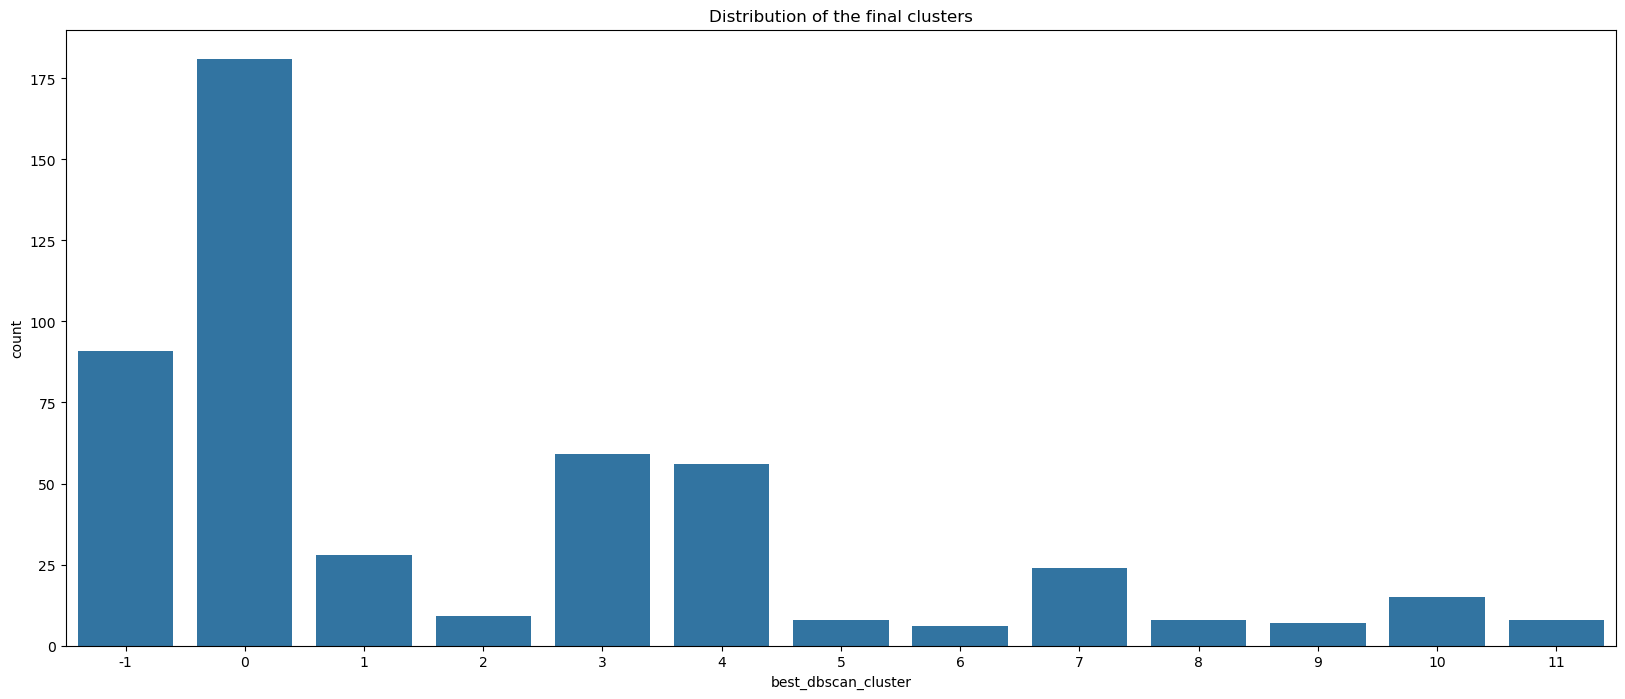

In [90]:
# Plot the number of products per cluster

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20,8))
sns.countplot(data=cluster_df,x="best_dbscan_cluster")
plt.title("Distribution of the final clusters")
plt.show()

In [91]:
# Collect the most frequent words to remove them in wordcloud

word_counts = np.asarray(X.sum(axis=0)).flatten()  # Sum per column

# Dataframe with frequencies per word

df_vocab = pd.DataFrame({
    'word': list(vectorizer.vocabulary_.keys()),
    'index': list(vectorizer.vocabulary_.values()),
    'frequency': [word_counts[idx] for idx in vectorizer.vocabulary_.values()]
})

df_vocab = df_vocab.sort_values(by='frequency', ascending=False).reset_index(drop=True)

df_vocab.head(50)


,word,index,frequency
0,pocket,2221,28.676704
1,organic,2047,25.936841
2,cotton,663,25.434849
3,polyester,2230,24.110393
4,recyclable,2379,22.880550
5,fabric,1060,22.573677
6,common,579,22.373340
7,program,2285,22.351789
8,thread,3107,22.331868
9,recycling,2382,22.150341


After analyzing the word frequencies, we identified that the top 9 most frequent terms are overly generic (e.g., pocket, fabric, organic) and do not add meaningful value to cluster interpretation. We have therefore removed them from the vocabulary for cleaner wordcloud visualizations.

In [92]:
# List of 9 concerned words

TOP9_WORDS = df_vocab['word'].head(9).tolist()


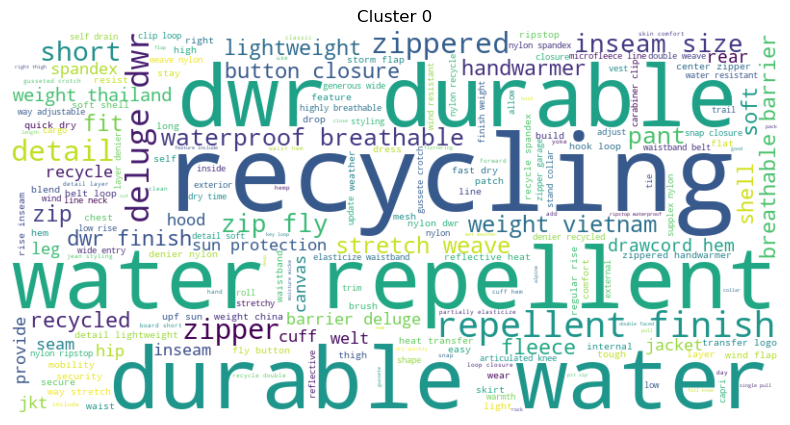

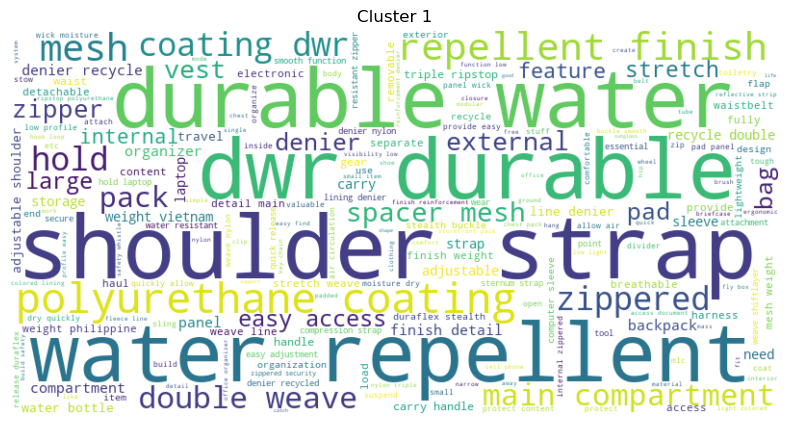

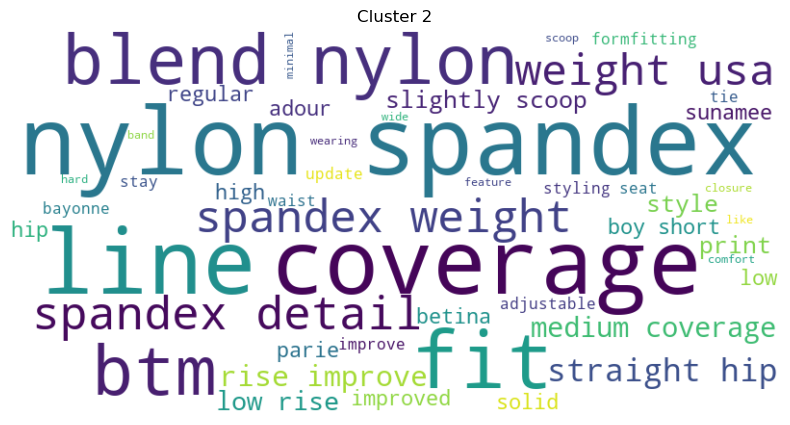

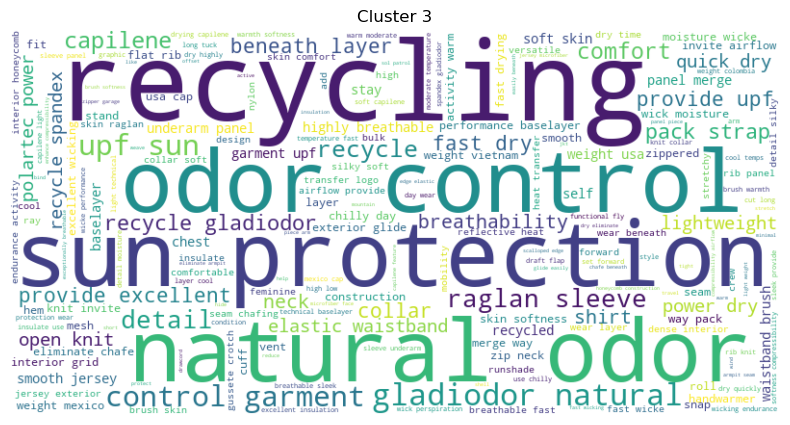

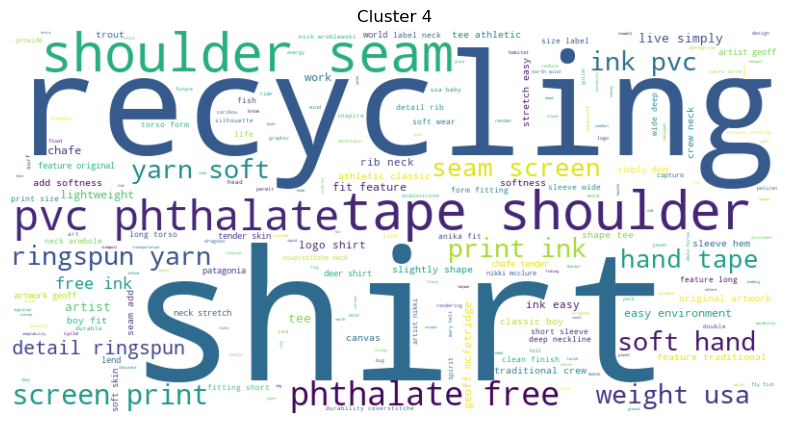

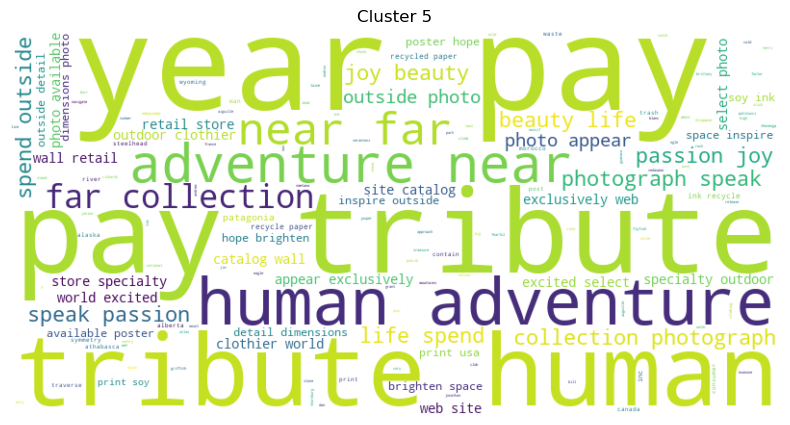

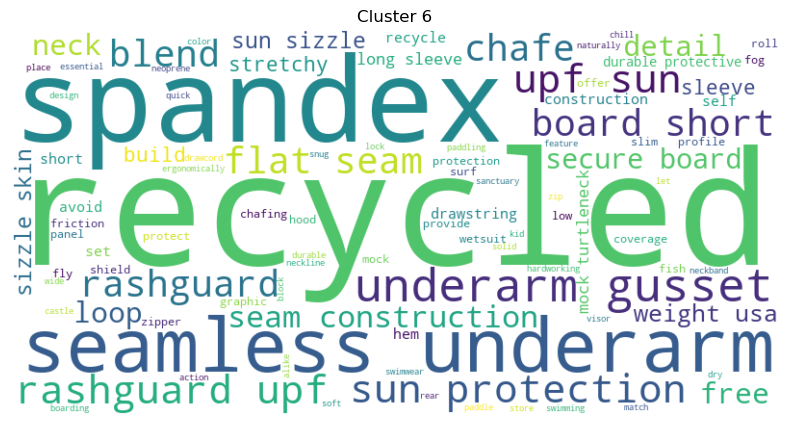

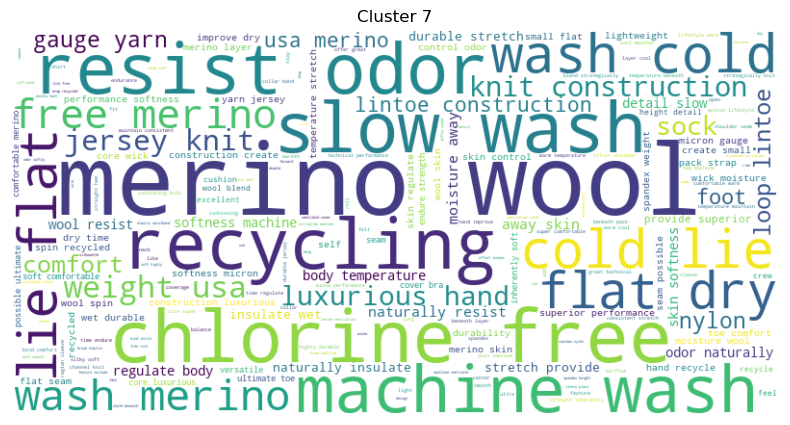

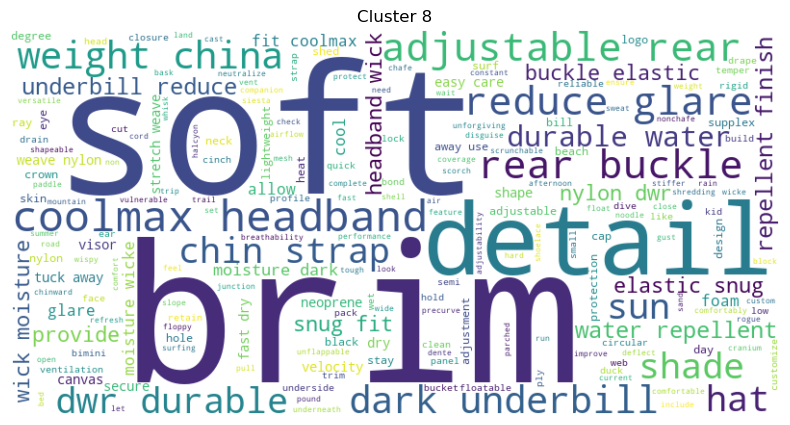

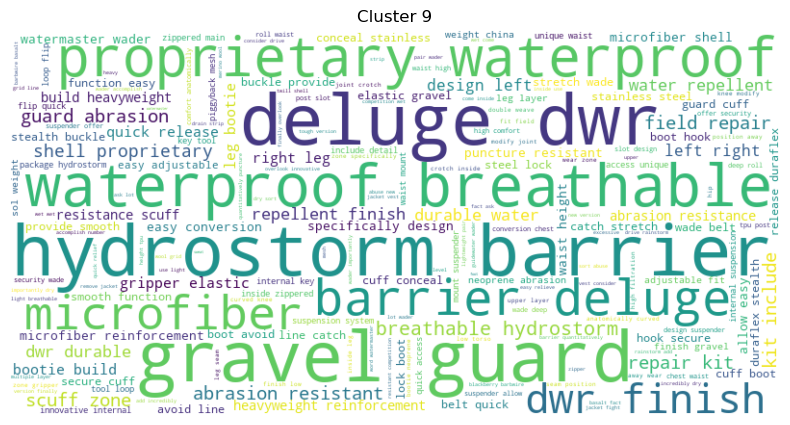

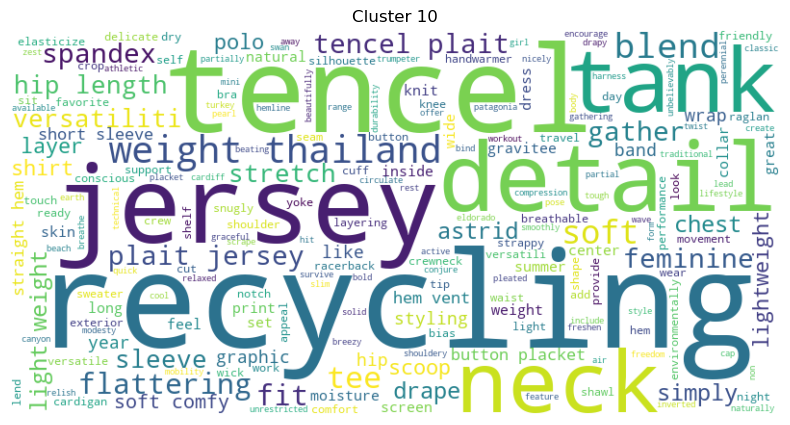

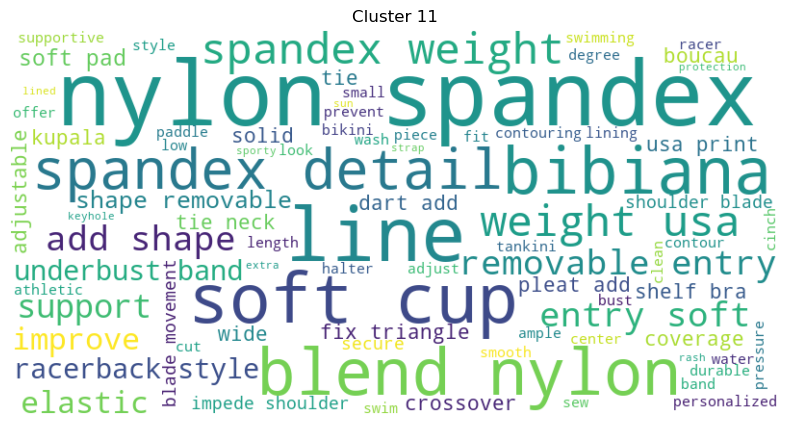

In [93]:
# Wordcloud visualization

from wordcloud import WordCloud

# Wordcloud for each valid cluster (remove -1)

valid_clusters = [c for c in clusters if c != -1]

# Wordcloud for each valid cluster

for c in valid_clusters:
    sub_cat = cluster_df.query(f"best_dbscan_cluster == {c}")
    corpus = " ".join([str(item) for item in sub_cat["clean_token"].to_list()])
    doc = nlp(corpus)

    stopwords_extended = set(STOP_WORDS) | set(TOP9_WORDS)
    wd = WordCloud(stopwords=stopwords_extended, background_color='white', width=800, height=400)
    cloud = wd.generate(doc.text)

    plt.figure(figsize=(10, 5))
    plt.imshow(cloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Cluster {c}")
    plt.show()

### Final Remarks on Clustering Interpretability

The DBSCAN clustering applied to The North Face product descriptions successfully revealed several interpretable and thematically consistent groups. Clusters 0, 1, 2, 3, 7, and 11 are especially clear in their semantics. They group products around shared material characteristics and usage contexts: waterproof technical apparel, backpacks, stretch and fit-focused clothing, sun-protective layers, merino wool undergarments, and swimwear with support features, respectively.

Clusters 6 and 10 also exhibit promising coherence, although some terms remain generic or overlapping. Cluster 10 notably captures feminine, lightweight apparel made from sustainable materials (e.g., *tencel*, *tank*, *jersey*), while Cluster 6 may relate to aquatic or board sports clothing (*rashguard*, *seamless*, *underarm*).

In contrast, Clusters 4, 5, 8, and 9 present weaker thematic focus. Cluster 5, for instance, contains abstract and editorial language (*tribute*, *collection*, *human*), likely stemming from marketing copy. Cluster 9 and parts of Cluster 4 involve vague or overly generic technical terms that do not aid meaningful segmentation. Cluster 8 mixes accessories and material terms inconsistently.

Finally, Cluster 10 shows moderate coherence but may benefit from further filtering, and Cluster 11 stands out as highly focused and useful for practical recommendation systems.

In conclusion, the unsupervised approach proves valuable to uncover latent product groupings, especially when supported by rich and descriptive text. Nevertheless, a manual review remains essential to discard or reinterpret noisy clusters. Future improvements could include metadata enrichment, hybrid clustering approaches, or supervised learning built on top of the most interpretable clusters.


## 2. 🛒 Building a Recommender System

In [94]:
# Come back to cluster_df

cluster_df.head()

,id,title,description,clean_token,best_dbscan_cluster
0,1,Active classic boxers,There's a reason why our boxers are a cult fav...,active classic boxer reason boxer cult favorit...,3
1,2,Active sport boxer briefs,Skinning up Glory requires enough movement wit...,active sport boxer brief skin glory require mo...,-1
2,3,Active sport briefs,These superbreathable no-fly briefs are the mi...,active sport brief superbreathable fly brief m...,3
3,4,Alpine guide pants,"Skin in, climb ice, switch to rock, traverse a...",alpine guide pant skin climb ice switch rock t...,0
4,5,Alpine wind jkt,"On high ridges, steep ice and anything alpine,...",alpine wind jkt high ridge steep ice alpine ja...,0


In [95]:
# Recommendation function


def find_similar_items(product_id, df, n_recommendations=5):  # function of product_id and a dataframe

    # Check that id is ok

    if product_id not in df['id'].values:
        print(f"❌ Product ID {product_id} not found.")
        return

    # Retrieve infos from id in df

    product_row = df[df['id'] == product_id].iloc[0]
    cluster_id = product_row['best_dbscan_cluster']
    title = product_row['title']
    description = product_row['description']

    # Print these infos

    print(f"🔎 You selected product ID #{product_id}")
    print(f"🧢 Title: {title}")
    print(f"📝 Description: {description}\n")

    # Outlier case

    if cluster_id == -1:
        print("⚠️ This item is an outlier and does not belong to any cluster.")
        print("🔄 Still suggesting 5 random items from the dataset...\n")
        recommendations = df[df['id'] != product_id].sample(n_recommendations)

    else:
        
        same_cluster = df[(df['best_dbscan_cluster'] == cluster_id) & (df['id'] != product_id)]

        if same_cluster.empty:
            print("⚠️ No other items in the same cluster. Showing random suggestions...\n")
            recommendations = df[df['id'] != product_id].sample(n_recommendations)
            
        else:
            print(f"✅ This product is part of cluster #{cluster_id}.")
            print(f"🧭 Here are {min(n_recommendations, len(same_cluster))} similar items:\n")
            recommendations = same_cluster.sample(min(n_recommendations, len(same_cluster)))

    for _, row in recommendations.iterrows():
        print(f"→ ID #{row['id']} — {row['title']}")
        print(f"   Description: {row['description']}\n")


In [101]:
# Check the function application

item_id = int(input("Enter a product ID (row number): "))
find_similar_items(item_id, cluster_df)


🔎 You selected product ID #47
🧢 Title: Girl's cotton tank dress
📝 Description: This soft cotton dress feels breezy and cool, just like a day at the beach. Made of a lightweight 5-oz 100% organic cotton jersey-knit fabric that breathes naturally and rests smoothly against skin. The partially elasticized waist provides shape and a flattering fit; it also encourages a full range of mobility. The versatile tank-top styling layers nicely, and pleated handwarmer pockets and front gathering details create a flattering fit. The hemline is just above the knees. Recyclable through the Common Threads Recycling Program.<br><br><b>Details:</b><ul> <li>Soft organic cotton jersey knit</li> <li>Tank style great for layering or alone</li> <li>Partial elasticized waist gives shape and comfort for freedom of movement</li> <li>Handwarmer pockets</li> <li>Hem hits above knee</li></ul><br><br><b>Fabric: </b>5-oz 100% organic cotton jersey. Recyclable through the Common Threads Recycling Program<br><br><b>We

The recommendation function appears to be working as expected.

However, the system could be further improved by ranking items within each cluster based on cosine similarity, rather than selecting them at random. This would ensure that the most relevant and closest items are prioritized in the recommendations.

## 3. 🧠 Topic Modeling with LSA

In [127]:
# Vectorization of clean_token

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(data['clean_token'])


In [128]:
# 20 topics defined - application of Truncated SVD

from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=20, random_state=42)
lsa_matrix = svd.fit_transform(X)


In [129]:
# print topics


# Get the vocabulary terms from the TF-IDF vectorizer
terms = vectorizer.get_feature_names_out()

# Loop over each topic/component from the SVD (LSA) model
for i, comp in enumerate(svd.components_):
    # Zip the vocabulary terms with their corresponding weight in the current topic
    terms_comp = zip(terms, comp)
    
    # Sort the terms by their importance (highest weight first) in this topic
    sorted_terms = sorted(terms_comp, key=lambda x: x[1], reverse=True)[:10]
    
    # Extract the top 10 terms as a list of strings
    top_words = [t[0] for t in sorted_terms]
    
    # Print the topic index and its top 10 representative words
    print(f"🧠 Topic {i}: {' | '.join(top_words)}")



🧠 Topic 0: pocket | organic | cotton | recyclable | polyester | common | program | thread | recycling | fabric
🧠 Topic 1: organic | cotton | shirt | print | ringspun | phthalate | pvc | ink | tape | screen
🧠 Topic 2: merino | odor | wool | control | gladiodor | natural | capilene | skin | wash | knit
🧠 Topic 3: inseam | organic | cotton | button | short | canvas | jean | fly | welt | size
🧠 Topic 4: merino | wool | wash | machine | slow | lie | naturally | resist | cold | core
🧠 Topic 5: nylon | sun | spandex | upf | coverage | protection | rise | print | blend | usa
🧠 Topic 6: spandex | coverage | tencel | blend | line | cotton | organic | hip | bra | jersey
🧠 Topic 7: strap | mesh | polyurethane | denier | pocket | compartment | coating | shoulder | hold | access
🧠 Topic 8: sun | upf | protection | collar | recycled | polyester | reflective | rashguard | runshade | sleeve
🧠 Topic 9: fleece | spandex | wind | stretch | brush | warmth | handwarmer | interior | trim | waistband
🧠 Topic 

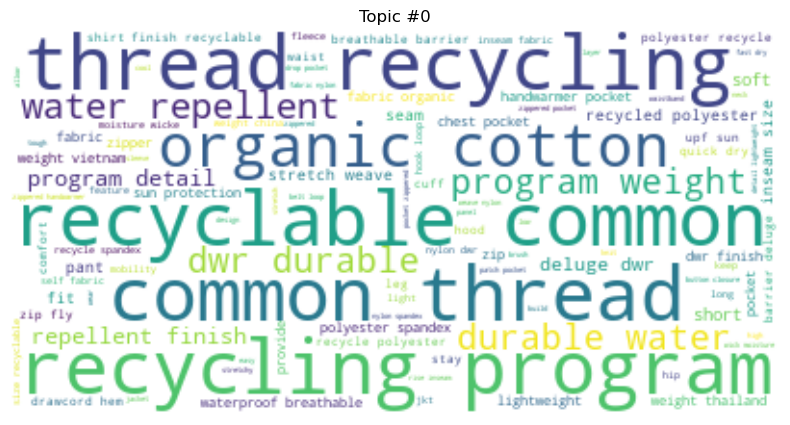

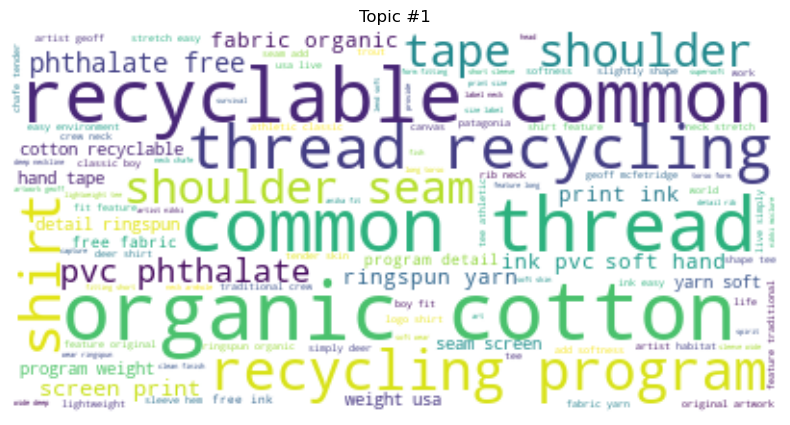

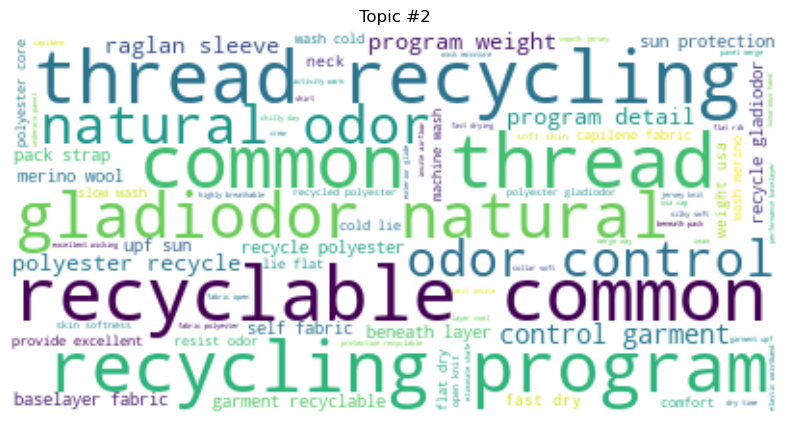

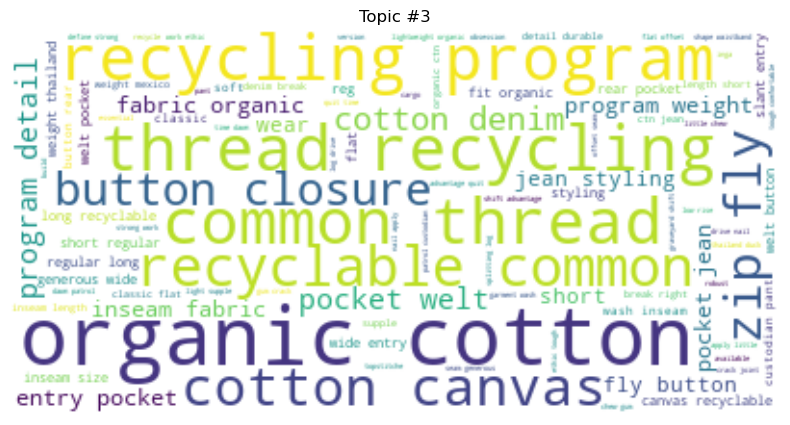

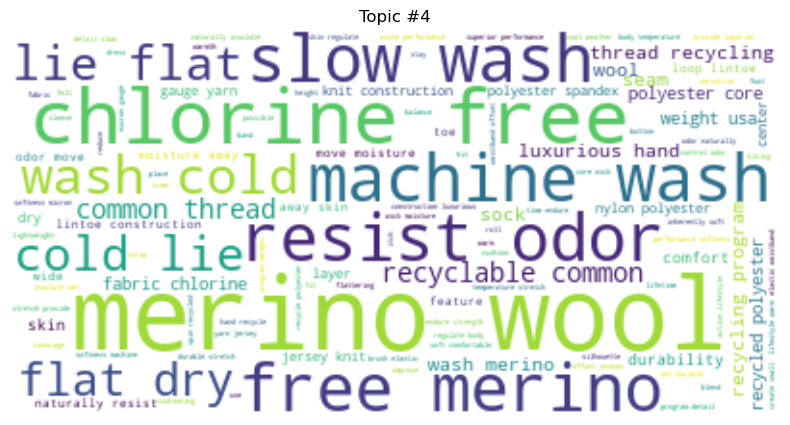

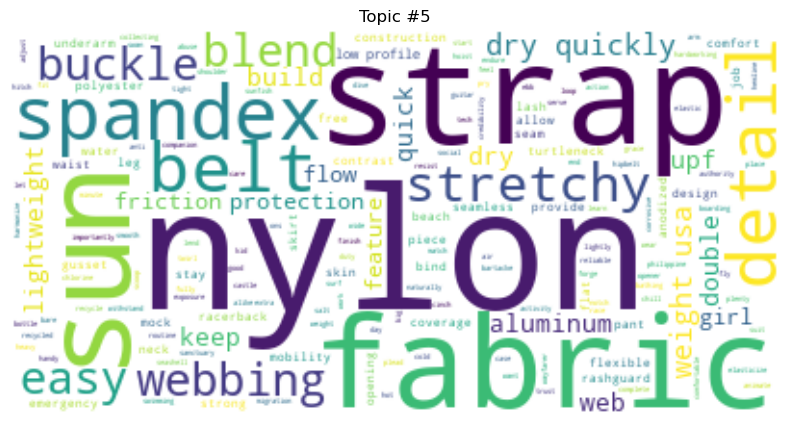

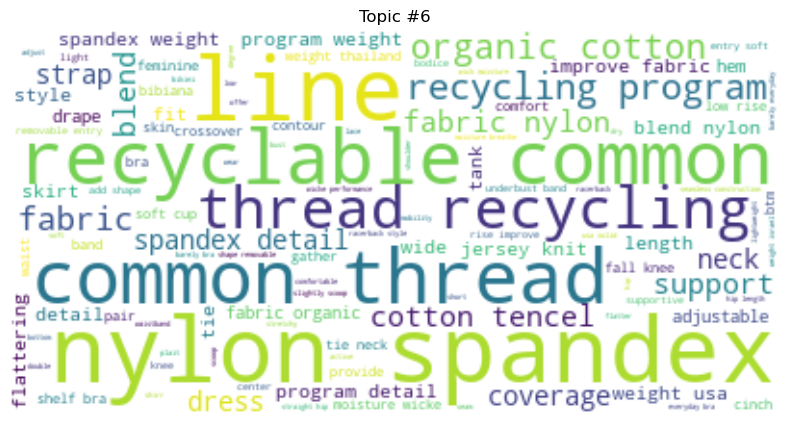

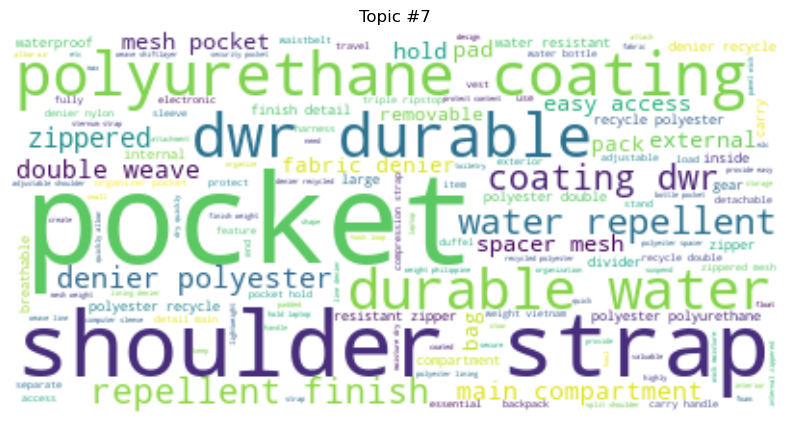

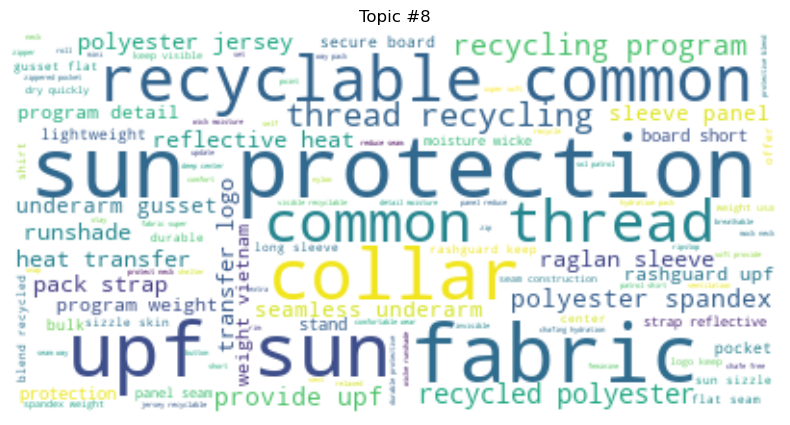

⚠️ Topic #9 has no associated documents.


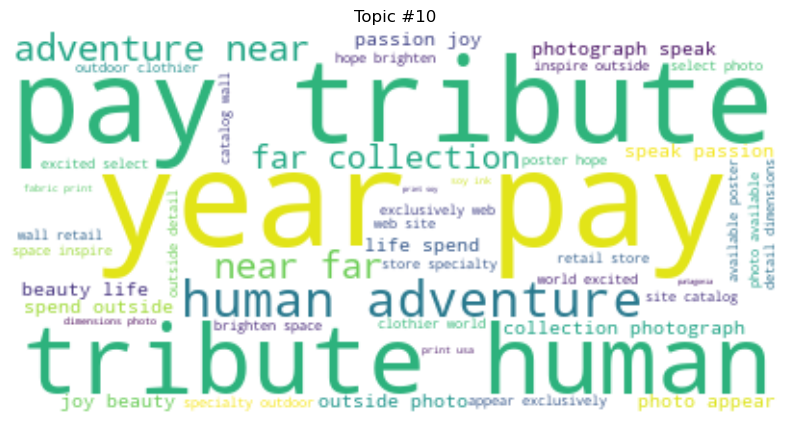

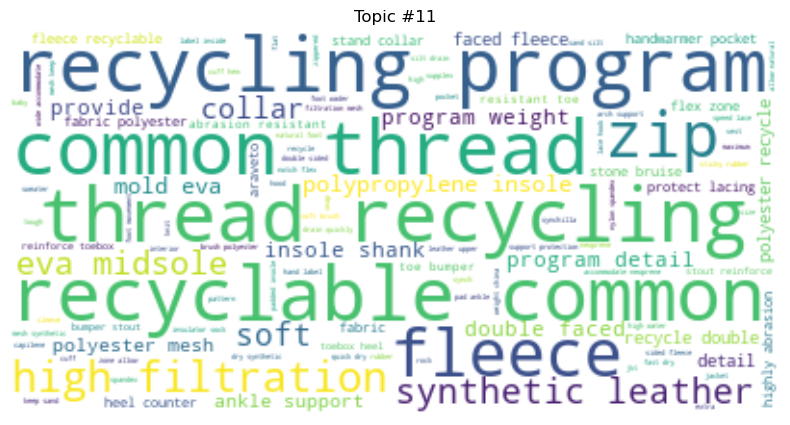

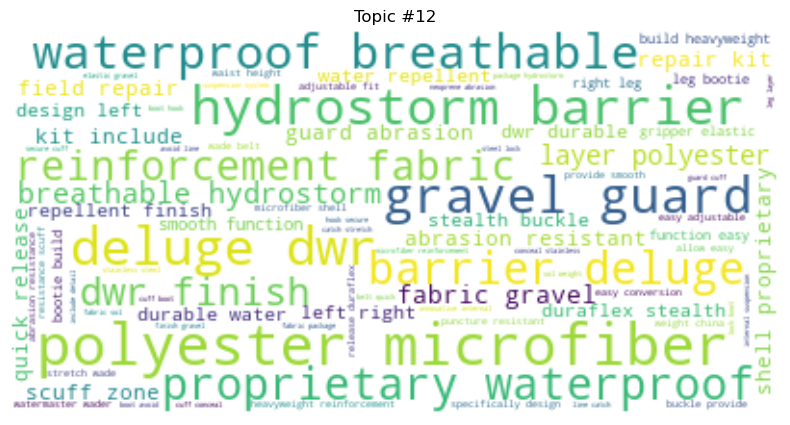

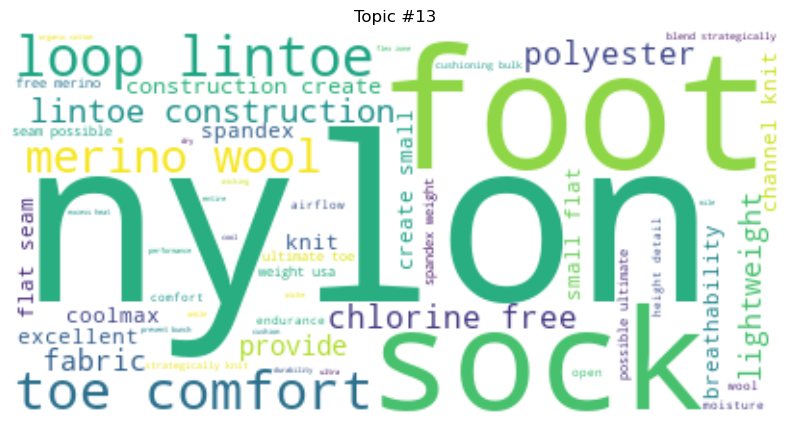

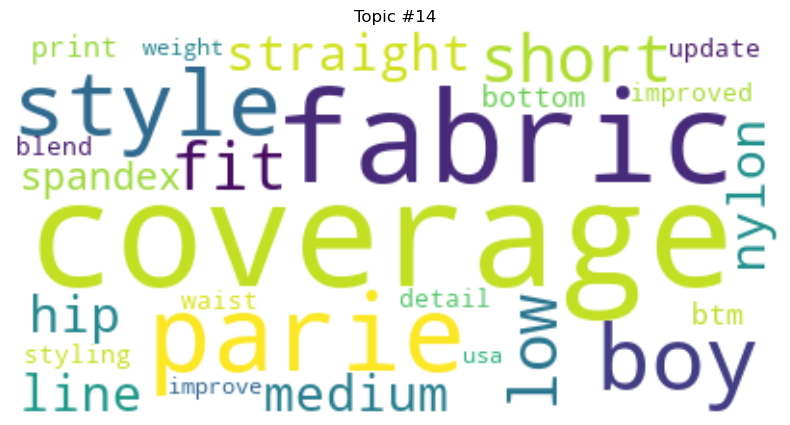

⚠️ Topic #15 has no associated documents.
⚠️ Topic #16 has no associated documents.
⚠️ Topic #17 has no associated documents.
⚠️ Topic #18 has no associated documents.
⚠️ Topic #19 has no associated documents.


In [131]:
# print wordclouds


# Loop through each topic identified by TruncatedSVD
for topic_idx in range(svd.n_components):
    
    # Select all documents where this topic is the main topic
    topic_docs = data[data['main_topic'] == topic_idx]

     # Skip if the topic has no documents
    if topic_docs.empty:
        print(f"⚠️ Topic #{topic_idx} has no associated documents.")
        continue
    
    # Combine the cleaned tokens into one large text string
    # Note: this assumes 'clean_token' is already joined as text; otherwise it should be joined manually
    text = " ".join(topic_docs['clean_token'].values)
    
    # Generate a word cloud from the topic's text
    wc = WordCloud(background_color='white').generate(text)
    
    # Plot the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')  # smooth rendering
    plt.axis('off')                           # hide axes
    plt.title(f"Topic #{topic_idx}")          # display topic number
    plt.show()



Topic modeling via LSA revealed semantically meaningful product groupings that go beyond traditional catalog categories. While some topics remain too generic or editorial to act on directly, many others offer clear thematic structure that can support navigation design, recommendation systems, product tagging, and targeted marketing.
For maximum impact, this analysis could be combined with user behavior data to map these topics to real conversion rates or engagement metrics.
